# 1. 20~23년 4개년 데이터 병합

In [6]:
import pandas as pd

In [7]:
# Set pandas display options
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 100)        # Set the display width to 1000 characters
pd.set_option('display.max_colwidth', None) # Allow the full content of each column to be displayed

In [8]:
import pyreadstat
df20, meta20 = pyreadstat.read_sas7bdat('hn20_all.sas7bdat')

In [9]:
var_label = meta20.column_names_to_labels

In [10]:
import pyreadstat
df21, meta21 = pyreadstat.read_sas7bdat('hn21_all.sas7bdat')

In [11]:
import pyreadstat
df22, meta22 = pyreadstat.read_sas7bdat('hn22_all.sas7bdat')

In [12]:
import pyreadstat
df23, meta23 = pyreadstat.read_sas7bdat('hn23_all.sas7bdat')

# 1-1. 변수 레이블 추출

In [13]:
print("\n=== 변수 레이블 ===")
for name, label in zip(meta20.column_names, meta20.column_labels):
    print(f"{name}: {label}")


=== 변수 레이블 ===
mod_d: 최종 DB 수정일
ID: 개인아이디
ID_fam: 가구 아이디
year: 조사연도
region: 시도
town_t: 동읍면
apt_t: 주택유형
psu: 조사구번호
sex: 성별
age: 만나이
age_month: 월령
incm: 소득4분위수(개인)
ho_incm: 소득4분위수(가구)
incm5: 소득5분위수(개인)
ho_incm5: 소득5분위수(가구)
edu: 교육수준 재분류 코드
occp: 직업재분류 및 실업/비경제활동인구상태 코드
wt_hs: 가구조사 가중치
wt_itvex: 건강설문,검진조사 가중치
wt_oe: 구강검진검사 가중치
wt_ntr: 영양조사 가중치
wt_tot: 건강설문,검진,영양조사 가중치
wt_oent: 구강검진,영양 가중치
kstrata: 분산추정 층
cfam: 가구원수
genertn: 가구세대구성코드
allownc: 기초생활수급 여부
house: 주택소유여부
live_t: 주택형태
ainc_unit1: 가구총소득(개방형): 소득단위
ainc_1: 가구총소득(개방형): 소득액
ainc: 월평균 가구총소득
marri_1: 결혼여부
marri_2: 결혼상태
fam_rela: 가구주와의 관계
tins: 건강보험종류
npins: 민간의료보험가입여부
ID_F: 아버지 아이디
ID_M: 어머니 아이디
D_1_1: 주관적 건강인지
D_2_1: 최근2주간 몸이 불편했던 경험 유무
D_2_wk: 최근2주간 불편감일수
DI1_dg: 고혈압 의사진단 여부
DI1_ag: 고혈압 진단시기
DI1_pr: 고혈압 현재 유병 여부
DI1_pt: 고혈압 치료
DI1_2: 혈압조절제 복용
DI2_dg: 이상지질혈증 의사진단 여부
DI2_ag: 이상지질혈증 진단시기
DI2_pr: 이상지질혈증 현재 유병 여부
DI2_pt: 이상지질혈증 치료
DI2_2: 이상지질혈증 약복용
DI3_dg: 뇌졸중 의사진단 여부
DI3_ag: 뇌졸중 진단시기
DI3_pr: 뇌졸중 현재 유병 여부
DI3_pt: 뇌졸중 치료
DI3_2: 뇌졸중 후유증
D

### 개인식별 변수(Key variables)

In [14]:
key = ['ID', 'year', 'sex']

### 범주형 변수

In [15]:
# 범주형 변수 (categorical columns)
cat_col = [
    'HE_obe',     # 고강도 신체활동 여부(일)
    'BO1_1',
    'BO1_2',
    'BO1_3',
    'BD1_11',
    'BD2_1',
    'BS3_1',
    'BE3_71',
    'BE3_75',
    'BE3_81',
    'BE3_91',
    'pa_aerobic',
    'L_BR_FQ',
    'BP1',
    'mh_stress',
    'incm',
    'ho_incm',
    'edu',
    'BH1']

### 연속형 변수

In [16]:
# 업데이트된 연속형 변수 (numerical columns)
num_col = [
    # [기존 신체 계측 변수]
    'HE_BMI',    # 체질량지수
    'HE_wc',     # 허리둘레
    'HE_wt',     # 체중
    
    # [기존 영양 섭취 변수]
    'N_EN',      # 에너지 섭취량(kcal)
    'N_CHO',     # 탄수화물 섭취량(g)
    'N_SUGAR',   # 당 섭취량(g)
    
    # [신규 추가: 상충 방지 및 임상적 중재용]
    'N_NA',      # 나트륨 섭취량(mg) -> 고혈압 중재의 핵심
    'N_FAT',     # 지방 섭취량(g) -> 탄수화물 제한 시 상충 모니터링
    'N_SFA',     # 포화지방산 섭취량(g) -> 심혈관 리스크 관리
    'N_TDF',     # 식이섬유 섭취량(g) -> 당뇨/혈압 보완적 가이드
    'N_K',       # 칼륨 섭취량(mg) -> 나트륨 배출 가이드
    'N_PROT'     # 단백질 섭취량(g) -> 전반적 영양 균형
]

### 종속변수: 당뇨병 유병여부(HE_DM_HbA1c) (1=정상 / 3=당뇨병)

### 종속변수: 고혈압 유병여부(HE_HP) 1=정상 / 4=고혈압)

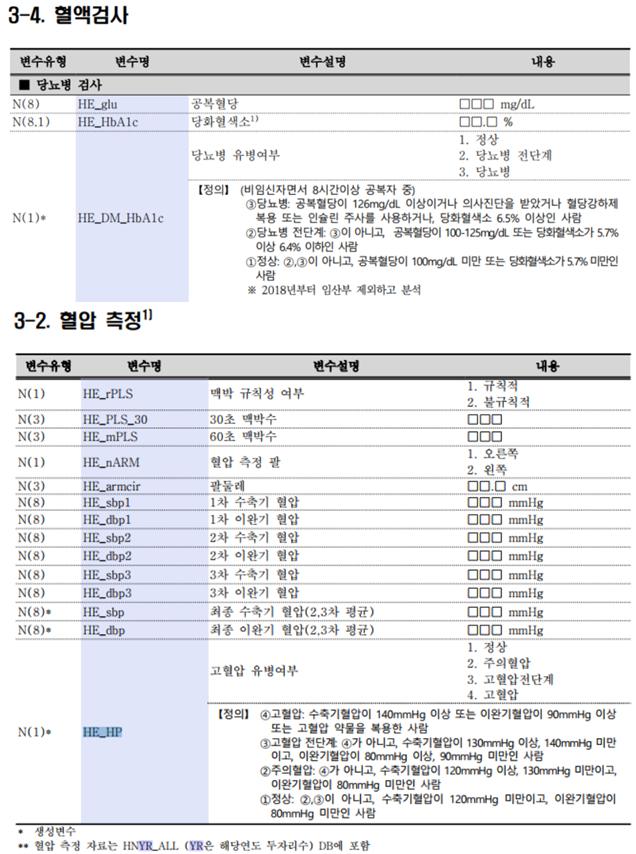

In [17]:
target_col = [
    'HE_DM_HbA1c',        # 당뇨병 유병여부 (1=정상 / 3=당뇨병)
    'HE_HP'        # 고혈압 유병여부 (1=정상 / 4=고혈압)
]

In [18]:
all_vars = key + cat_col + num_col + target_col

# 1-2. 선정 변수로 데이터 필터

In [19]:
df20_sel = df20[all_vars].copy()

In [20]:
df21_sel = df21[all_vars].copy()

In [21]:
df22_sel = df22[all_vars].copy()

In [22]:
df23_sel = df23[all_vars].copy()

In [23]:
df_total = pd.concat([df20_sel, df21_sel, df22_sel, df23_sel], axis=0).reset_index(drop=True).copy()

In [24]:
df_total

,ID,year,sex,HE_obe,BO1_1,BO1_2,BO1_3,BD1_11,BD2_1,BS3_1,BE3_71,BE3_75,BE3_81,BE3_91,pa_aerobic,L_BR_FQ,BP1,mh_stress,incm,ho_incm,edu,BH1,HE_BMI,HE_wc,HE_wt,N_EN,N_CHO,N_SUGAR,N_NA,N_FAT,N_SFA,N_TDF,N_K,N_PROT,HE_DM_HbA1c,HE_HP
0,A801169401,2020.0,1.0,3.0,2.0,1.0,8.0,3.0,3.0,3.0,2.0,2.0,2.0,1.0,0.0,4.0,3.0,0.0,1.0,2.0,4.0,1.0,24.185489,85.8,78.10,2368.369886,394.868142,48.990887,7280.584440,37.615033,13.254372,22.810607,2962.954948,98.960023,1.0,1.0
1,A801169402,2020.0,2.0,1.0,1.0,8.0,8.0,1.0,8.0,8.0,2.0,2.0,2.0,2.0,0.0,4.0,3.0,0.0,1.0,2.0,4.0,1.0,17.935939,68.0,53.00,1545.134310,292.311888,96.069854,2843.444639,19.146147,5.348099,25.461679,1656.809085,49.469332,1.0,1.0
2,A801169403,2020.0,1.0,NaN,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,NaN,1.0,8.0,NaN,1.0,2.0,1.0,8.0,13.997271,53.2,27.20,1743.531644,293.211971,51.820406,2807.681976,26.514822,8.305549,20.226269,2175.749058,76.621307,NaN,NaN
3,A801169404,2020.0,1.0,NaN,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,NaN,1.0,8.0,NaN,1.0,2.0,1.0,8.0,16.517345,50.1,27.70,1764.874765,264.937540,37.216848,2693.714618,46.343861,11.383914,12.734746,1349.771043,61.500325,NaN,NaN
4,A801169405,2020.0,1.0,NaN,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,NaN,1.0,8.0,NaN,1.0,2.0,1.0,8.0,14.094637,NaN,17.46,1202.218977,167.185836,24.958173,2127.904083,36.155763,8.839926,10.507641,1464.707749,46.773405,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27638,YR62368101,2023.0,1.0,3.0,2.0,2.0,8.0,3.0,1.0,3.0,2.0,2.0,2.0,2.0,0.0,1.0,3.0,0.0,2.0,1.0,1.0,2.0,24.001128,97.0,63.30,1346.633466,176.374744,29.055900,4205.080845,39.510729,10.382034,22.814195,2514.747021,65.732028,3.0,4.0
27639,YR62368102,2023.0,2.0,4.0,1.0,8.0,8.0,2.0,1.0,8.0,2.0,2.0,1.0,1.0,1.0,1.0,3.0,0.0,2.0,1.0,1.0,1.0,28.977553,97.0,71.70,1838.070072,217.031964,36.132563,1506.082656,71.923101,22.929784,16.499206,2220.887272,71.203663,2.0,4.0
27640,YR62370201,2023.0,2.0,2.0,1.0,8.0,8.0,3.0,1.0,8.0,2.0,2.0,2.0,1.0,1.0,1.0,3.0,0.0,1.0,1.0,3.0,1.0,19.093750,66.3,40.20,1686.294918,252.843274,36.251515,2260.089646,45.340514,9.532183,23.389437,2016.389197,64.894444,2.0,3.0
27641,YR62394401,2023.0,1.0,3.0,1.0,8.0,8.0,3.0,4.0,8.0,2.0,2.0,2.0,1.0,1.0,1.0,3.0,0.0,4.0,4.0,4.0,1.0,24.916409,87.6,74.40,1629.256388,267.084482,18.829615,4102.646329,26.367573,6.785000,23.357382,2577.319424,73.202963,2.0,3.0


# 1-3. 종속변수 전처리(당뇨병, 고혈압)

#### 당뇨병

In [25]:
# 당뇨병 (1=정상, 3=당뇨병)을 0,1로 변환
df_total['HE_DM_HbA1c'] = df_total['HE_DM_HbA1c'].map({1: 0, 3: 1}).fillna(-999)

#### 고혈압

In [26]:
# 고혈압 (1=정상, 4=고혈압)을 0,1로 변환
df_total['HE_HP'] = df_total['HE_HP'].map({1: 0, 4: 1}).fillna(-999)

In [27]:
# 변환 결과 확인
for col in ['HE_DM_HbA1c']:
   print(f"\n{col} unique values:", df_total[col].unique())
   print(f"{col} value counts:\n", df_total[col].value_counts())


HE_DM_HbA1c unique values: [   0. -999.    1.]
HE_DM_HbA1c value counts:
 -999.0    14213
 0.0       9997
 1.0       3433
Name: HE_DM_HbA1c, dtype: int64


In [28]:
# 변환 결과 확인
for col in ['HE_HP']:
   print(f"\n{col} unique values:", df_total[col].unique())
   print(f"{col} value counts:\n", df_total[col].value_counts())


HE_HP unique values: [   0. -999.    1.]
HE_HP value counts:
 -999.0    14323
 0.0       9517
 1.0       3803
Name: HE_HP, dtype: int64


In [29]:
import pandas as pd
import numpy as np

# 컬럼 정의
dm_col = 'HE_DM_HbA1c'
htn_col = 'HE_HP'
target_col = 'integrated_target'

# 조건 설정
conditions = [
    (df_total[dm_col] == 0) & (df_total[htn_col] == 0), # Class 0: 정상
    (df_total[dm_col] == 0) & (df_total[htn_col] == 1), # Class 1: 고혈압만
    (df_total[dm_col] == 1) & (df_total[htn_col] == 0), # Class 2: 당뇨만
    (df_total[dm_col] == 1) & (df_total[htn_col] == 1)  # Class 3: 복합 유병
]

# 클래스 할당
choices = [0, 1, 2, 3]
df_total[target_col] = np.select(conditions, choices, default=np.nan)

# 결과 확인
print(df_total[target_col].value_counts().sort_index())

0.0    5846
1.0    1056
2.0     641
3.0     992
Name: integrated_target, dtype: int64


In [30]:
df_total

,ID,year,sex,HE_obe,BO1_1,BO1_2,BO1_3,BD1_11,BD2_1,BS3_1,BE3_71,BE3_75,BE3_81,BE3_91,pa_aerobic,L_BR_FQ,BP1,mh_stress,incm,ho_incm,edu,BH1,HE_BMI,HE_wc,HE_wt,N_EN,N_CHO,N_SUGAR,N_NA,N_FAT,N_SFA,N_TDF,N_K,N_PROT,HE_DM_HbA1c,HE_HP,integrated_target
0,A801169401,2020.0,1.0,3.0,2.0,1.0,8.0,3.0,3.0,3.0,2.0,2.0,2.0,1.0,0.0,4.0,3.0,0.0,1.0,2.0,4.0,1.0,24.185489,85.8,78.10,2368.369886,394.868142,48.990887,7280.584440,37.615033,13.254372,22.810607,2962.954948,98.960023,0.0,0.0,0.0
1,A801169402,2020.0,2.0,1.0,1.0,8.0,8.0,1.0,8.0,8.0,2.0,2.0,2.0,2.0,0.0,4.0,3.0,0.0,1.0,2.0,4.0,1.0,17.935939,68.0,53.00,1545.134310,292.311888,96.069854,2843.444639,19.146147,5.348099,25.461679,1656.809085,49.469332,0.0,0.0,0.0
2,A801169403,2020.0,1.0,NaN,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,NaN,1.0,8.0,NaN,1.0,2.0,1.0,8.0,13.997271,53.2,27.20,1743.531644,293.211971,51.820406,2807.681976,26.514822,8.305549,20.226269,2175.749058,76.621307,-999.0,-999.0,NaN
3,A801169404,2020.0,1.0,NaN,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,NaN,1.0,8.0,NaN,1.0,2.0,1.0,8.0,16.517345,50.1,27.70,1764.874765,264.937540,37.216848,2693.714618,46.343861,11.383914,12.734746,1349.771043,61.500325,-999.0,-999.0,NaN
4,A801169405,2020.0,1.0,NaN,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,NaN,1.0,8.0,NaN,1.0,2.0,1.0,8.0,14.094637,NaN,17.46,1202.218977,167.185836,24.958173,2127.904083,36.155763,8.839926,10.507641,1464.707749,46.773405,-999.0,-999.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27638,YR62368101,2023.0,1.0,3.0,2.0,2.0,8.0,3.0,1.0,3.0,2.0,2.0,2.0,2.0,0.0,1.0,3.0,0.0,2.0,1.0,1.0,2.0,24.001128,97.0,63.30,1346.633466,176.374744,29.055900,4205.080845,39.510729,10.382034,22.814195,2514.747021,65.732028,1.0,1.0,3.0
27639,YR62368102,2023.0,2.0,4.0,1.0,8.0,8.0,2.0,1.0,8.0,2.0,2.0,1.0,1.0,1.0,1.0,3.0,0.0,2.0,1.0,1.0,1.0,28.977553,97.0,71.70,1838.070072,217.031964,36.132563,1506.082656,71.923101,22.929784,16.499206,2220.887272,71.203663,-999.0,1.0,NaN
27640,YR62370201,2023.0,2.0,2.0,1.0,8.0,8.0,3.0,1.0,8.0,2.0,2.0,2.0,1.0,1.0,1.0,3.0,0.0,1.0,1.0,3.0,1.0,19.093750,66.3,40.20,1686.294918,252.843274,36.251515,2260.089646,45.340514,9.532183,23.389437,2016.389197,64.894444,-999.0,-999.0,NaN
27641,YR62394401,2023.0,1.0,3.0,1.0,8.0,8.0,3.0,4.0,8.0,2.0,2.0,2.0,1.0,1.0,1.0,3.0,0.0,4.0,4.0,4.0,1.0,24.916409,87.6,74.40,1629.256388,267.084482,18.829615,4102.646329,26.367573,6.785000,23.357382,2577.319424,73.202963,-999.0,-999.0,NaN


In [31]:
# 1. 원인 파악: 어떤 조합에서 NaN이 생겼나?
print("타겟 생성 전 결측치 확인:")
print(df_total[[dm_col, htn_col]].isnull().sum())

# 2. NaN 행 제거 (독립변수 & 타겟이 없는 데이터는 제거)
df_total = df_total.dropna()

# 3. 타겟 변수를 정수형(int)으로 변환 (XGBoost 다중 분류 필수 사항)
df_total[target_col] = df_total[target_col].astype(int)

# 4. 결과 재확인
print("\n최종 타겟 분포:")
print(df_total[target_col].value_counts().sort_index())

타겟 생성 전 결측치 확인:
HE_DM_HbA1c    0
HE_HP          0
dtype: int64

최종 타겟 분포:
0    4910
1     910
2     501
3     812
Name: integrated_target, dtype: int64


C:\Users\miy\AppData\Local\Temp\ipykernel_9404\2826344703.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_total[target_col] = df_total[target_col].astype(int)


In [32]:
df_total = df_total.reset_index(drop=True)

In [33]:
df_total

,ID,year,sex,HE_obe,BO1_1,BO1_2,BO1_3,BD1_11,BD2_1,BS3_1,BE3_71,BE3_75,BE3_81,BE3_91,pa_aerobic,L_BR_FQ,BP1,mh_stress,incm,ho_incm,edu,BH1,HE_BMI,HE_wc,HE_wt,N_EN,N_CHO,N_SUGAR,N_NA,N_FAT,N_SFA,N_TDF,N_K,N_PROT,HE_DM_HbA1c,HE_HP,integrated_target
0,A801169401,2020.0,1.0,3.0,2.0,1.0,8.0,3.0,3.0,3.0,2.0,2.0,2.0,1.0,0.0,4.0,3.0,0.0,1.0,2.0,4.0,1.0,24.185489,85.8,78.1,2368.369886,394.868142,48.990887,7280.584440,37.615033,13.254372,22.810607,2962.954948,98.960023,0.0,0.0,0
1,A801169402,2020.0,2.0,1.0,1.0,8.0,8.0,1.0,8.0,8.0,2.0,2.0,2.0,2.0,0.0,4.0,3.0,0.0,1.0,2.0,4.0,1.0,17.935939,68.0,53.0,1545.134310,292.311888,96.069854,2843.444639,19.146147,5.348099,25.461679,1656.809085,49.469332,0.0,0.0,0
2,A801177904,2020.0,1.0,2.0,3.0,8.0,1.0,4.0,5.0,8.0,2.0,2.0,2.0,1.0,0.0,4.0,4.0,0.0,4.0,4.0,3.0,2.0,21.041694,74.9,61.6,3201.123130,369.321938,92.524157,2656.830553,118.414643,32.918946,19.255678,2615.647318,153.603737,0.0,0.0,0
3,A801230603,2020.0,1.0,4.0,2.0,3.0,8.0,4.0,5.0,3.0,2.0,1.0,2.0,1.0,1.0,2.0,2.0,1.0,3.0,3.0,4.0,2.0,27.685459,96.5,90.1,3216.070342,283.487397,86.894038,5137.009997,131.796273,27.884966,37.091581,6095.300423,221.732990,0.0,0.0,0
4,A801239102,2020.0,2.0,2.0,1.0,8.0,8.0,3.0,3.0,8.0,2.0,2.0,2.0,2.0,0.0,4.0,3.0,0.0,4.0,4.0,4.0,1.0,19.317196,73.9,52.4,1485.585451,208.854029,27.134827,2311.618621,59.221870,14.153842,15.004154,1241.717098,31.633701,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7128,YR62275101,2023.0,2.0,4.0,1.0,8.0,8.0,4.0,3.0,2.0,2.0,2.0,2.0,1.0,1.0,3.0,3.0,0.0,1.0,1.0,3.0,1.0,26.136064,90.6,68.0,719.190087,133.626415,10.251414,2546.452778,7.098739,1.872613,15.867905,1718.672823,26.827684,0.0,0.0,0
7129,YR62277102,2023.0,2.0,4.0,1.0,8.0,8.0,8.0,8.0,8.0,2.0,2.0,2.0,2.0,0.0,1.0,3.0,0.0,2.0,1.0,1.0,1.0,25.649503,87.7,60.2,1294.454663,189.260919,30.138238,3150.296459,37.650819,12.801828,23.854586,2216.975305,45.845444,0.0,1.0,1
7130,YR62315501,2023.0,2.0,3.0,1.0,8.0,8.0,8.0,8.0,8.0,2.0,2.0,1.0,1.0,1.0,1.0,2.0,1.0,3.0,3.0,1.0,1.0,23.733838,82.7,59.7,1067.107202,111.548102,33.397851,807.937161,44.286384,10.118248,16.505315,1962.694325,58.687782,1.0,1.0,3
7131,YR62319601,2023.0,2.0,5.0,2.0,1.0,8.0,8.0,8.0,8.0,2.0,2.0,2.0,2.0,1.0,1.0,3.0,0.0,3.0,2.0,1.0,1.0,30.021926,104.2,71.2,791.023494,136.258437,11.437553,2155.364506,12.466125,2.949610,13.090246,1261.026123,30.949946,1.0,1.0,3


In [34]:
# 1-5. 한글 컬럼으로 변환

def parse_labels(text):
    labels = {}
    for line in text.split('\n'):
        if ': ' in line:
            var, label = line.split(': ', 1)
            labels[var.strip()] = label.strip()
    return labels

# 변수 레이블 파싱 (최종 확장 버전)
label_dict = parse_labels("""
=== 변수 레이블 ===
ID: 개인아이디
year: 조사연도
sex: 성별
HE_DM_HbA1c: 당뇨병(당화혈색소 포함) 유병여부(19세이상)
HE_HP: 고혈압 유병여부
integrated_target: 복합 유병 상태
HE_obe: 비만 유병여부(19세이상)
BO1_1: (성인) 1년간 체중 변화 여부
BO1_2: (성인) 1년간 체중 감소량
BO1_3: (성인) 1년간 체중 증가량
BD1_11: (만12세이상) 1년간 음주빈도
BD2_1: (만12세이상) 한번에 마시는 음주량
BS3_1: (성인) 현재 일반담배(궐련) 흡연 여부
BE3_71: 고강도 신체활동 여부: 일
BE3_75: 고강도 신체활동 여부: 여가
BE3_81: 중강도 신체활동 여부: 일
BE3_91: 신체활동 여부: 장소이동
pa_aerobic: 유산소 신체활동 실천율
L_BR_FQ: 최근 1년동안 1주 동안 아침식사 빈도
BP1: 평소 스트레스 인지 정도
mh_stress: 스트레스 인지율
incm: 소득4분위수(개인)
ho_incm: 소득4분위수(가구)
edu: 교육수준 재분류 코드
BH1: (성인) 건강검진 수진 여부
HE_BMI: 체질량지수
HE_wc: 허리둘레
HE_wt: 체중
N_EN: 에너지 섭취량(kcal)
N_CHO: 탄수화물 섭취량(g)
N_SUGAR: 당 섭취량(g)
N_NA: 나트륨 섭취량(mg)
N_FAT: 지방 섭취량(g)
N_SFA: 포화지방산 섭취량(g)
N_TDF: 식이섬유 섭취량(g)
N_K: 칼륨 섭취량(mg)
N_PROT: 단백질 섭취량(g)
""")


# 변환 결과 확인
for col in cat_col:
   print(f"\n=== {col} 변환 결과 ===")
   print(df_total[col].value_counts())

df_total.rename(columns=label_dict, inplace=True)


=== HE_obe 변환 결과 ===
2.0    3283
4.0    1585
3.0    1497
1.0     488
5.0     249
6.0      31
Name: HE_obe, dtype: int64

=== BO1_1 변환 결과 ===
1.0    4365
3.0    1646
2.0    1121
9.0       1
Name: BO1_1, dtype: int64

=== BO1_2 변환 결과 ===
8.0    6011
1.0     815
2.0     198
3.0     108
9.0       1
Name: BO1_2, dtype: int64

=== BO1_3 변환 결과 ===
8.0    5486
1.0    1279
2.0     270
3.0      97
9.0       1
Name: BO1_3, dtype: int64

=== BD1_11 변환 결과 ===
4.0    1718
2.0    1499
1.0    1297
5.0     868
3.0     829
8.0     627
6.0     295
Name: BD1_11, dtype: int64

=== BD2_1 변환 결과 ===
1.0    2042
8.0    1924
2.0    1069
4.0     791
5.0     674
3.0     633
Name: BD2_1, dtype: int64

=== BS3_1 변환 결과 ===
8.0    4677
3.0    1486
1.0     813
2.0     157
Name: BS3_1, dtype: int64

=== BE3_71 변환 결과 ===
2.0    6999
1.0     134
Name: BE3_71, dtype: int64

=== BE3_75 변환 결과 ===
2.0    6144
1.0     989
Name: BE3_75, dtype: int64

=== BE3_81 변환 결과 ===
2.0    6319
1.0     814
Name: BE3_81, dtype: int64

===

In [35]:
df_total

,개인아이디,조사연도,성별,비만 유병여부(19세이상),(성인) 1년간 체중 변화 여부,(성인) 1년간 체중 감소량,(성인) 1년간 체중 증가량,(만12세이상) 1년간 음주빈도,(만12세이상) 한번에 마시는 음주량,(성인) 현재 일반담배(궐련) 흡연 여부,고강도 신체활동 여부: 일,고강도 신체활동 여부: 여가,중강도 신체활동 여부: 일,신체활동 여부: 장소이동,유산소 신체활동 실천율,최근 1년동안 1주 동안 아침식사 빈도,평소 스트레스 인지 정도,스트레스 인지율,소득4분위수(개인),소득4분위수(가구),교육수준 재분류 코드,(성인) 건강검진 수진 여부,체질량지수,허리둘레,체중,에너지 섭취량(kcal),탄수화물 섭취량(g),당 섭취량(g),나트륨 섭취량(mg),지방 섭취량(g),포화지방산 섭취량(g),식이섬유 섭취량(g),칼륨 섭취량(mg),단백질 섭취량(g),당뇨병(당화혈색소 포함) 유병여부(19세이상),고혈압 유병여부,복합 유병 상태
0,A801169401,2020.0,1.0,3.0,2.0,1.0,8.0,3.0,3.0,3.0,2.0,2.0,2.0,1.0,0.0,4.0,3.0,0.0,1.0,2.0,4.0,1.0,24.185489,85.8,78.1,2368.369886,394.868142,48.990887,7280.584440,37.615033,13.254372,22.810607,2962.954948,98.960023,0.0,0.0,0
1,A801169402,2020.0,2.0,1.0,1.0,8.0,8.0,1.0,8.0,8.0,2.0,2.0,2.0,2.0,0.0,4.0,3.0,0.0,1.0,2.0,4.0,1.0,17.935939,68.0,53.0,1545.134310,292.311888,96.069854,2843.444639,19.146147,5.348099,25.461679,1656.809085,49.469332,0.0,0.0,0
2,A801177904,2020.0,1.0,2.0,3.0,8.0,1.0,4.0,5.0,8.0,2.0,2.0,2.0,1.0,0.0,4.0,4.0,0.0,4.0,4.0,3.0,2.0,21.041694,74.9,61.6,3201.123130,369.321938,92.524157,2656.830553,118.414643,32.918946,19.255678,2615.647318,153.603737,0.0,0.0,0
3,A801230603,2020.0,1.0,4.0,2.0,3.0,8.0,4.0,5.0,3.0,2.0,1.0,2.0,1.0,1.0,2.0,2.0,1.0,3.0,3.0,4.0,2.0,27.685459,96.5,90.1,3216.070342,283.487397,86.894038,5137.009997,131.796273,27.884966,37.091581,6095.300423,221.732990,0.0,0.0,0
4,A801239102,2020.0,2.0,2.0,1.0,8.0,8.0,3.0,3.0,8.0,2.0,2.0,2.0,2.0,0.0,4.0,3.0,0.0,4.0,4.0,4.0,1.0,19.317196,73.9,52.4,1485.585451,208.854029,27.134827,2311.618621,59.221870,14.153842,15.004154,1241.717098,31.633701,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7128,YR62275101,2023.0,2.0,4.0,1.0,8.0,8.0,4.0,3.0,2.0,2.0,2.0,2.0,1.0,1.0,3.0,3.0,0.0,1.0,1.0,3.0,1.0,26.136064,90.6,68.0,719.190087,133.626415,10.251414,2546.452778,7.098739,1.872613,15.867905,1718.672823,26.827684,0.0,0.0,0
7129,YR62277102,2023.0,2.0,4.0,1.0,8.0,8.0,8.0,8.0,8.0,2.0,2.0,2.0,2.0,0.0,1.0,3.0,0.0,2.0,1.0,1.0,1.0,25.649503,87.7,60.2,1294.454663,189.260919,30.138238,3150.296459,37.650819,12.801828,23.854586,2216.975305,45.845444,0.0,1.0,1
7130,YR62315501,2023.0,2.0,3.0,1.0,8.0,8.0,8.0,8.0,8.0,2.0,2.0,1.0,1.0,1.0,1.0,2.0,1.0,3.0,3.0,1.0,1.0,23.733838,82.7,59.7,1067.107202,111.548102,33.397851,807.937161,44.286384,10.118248,16.505315,1962.694325,58.687782,1.0,1.0,3
7131,YR62319601,2023.0,2.0,5.0,2.0,1.0,8.0,8.0,8.0,8.0,2.0,2.0,2.0,2.0,1.0,1.0,3.0,0.0,3.0,2.0,1.0,1.0,30.021926,104.2,71.2,791.023494,136.258437,11.437553,2155.364506,12.466125,2.949610,13.090246,1261.026123,30.949946,1.0,1.0,3


In [36]:
df_total.to_csv('./국건영_4개년_복합유병여부_251226.csv', index=False, encoding='utf-8-sig')

### 당뇨병 / 고혈압 데이터 전처리 완

In [37]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.utils.class_weight import compute_sample_weight

# [1] 연속형 변수 (Numerical Columns) - DiCE가 미세 조절할 핵심 수치
num_col = [
    '체질량지수', '허리둘레', '체중',
    '에너지 섭취량(kcal)', '탄수화물 섭취량(g)', '당 섭취량(g)',
    '나트륨 섭취량(mg)', '지방 섭취량(g)', '포화지방산 섭취량(g)',
    '식이섬유 섭취량(g)', '칼륨 섭취량(mg)', '단백질 섭취량(g)'
]

# [2] 범주형 변수 (Categorical Columns) - DiCE가 상태를 교체할 변수
cat_col = [
    '비만 유병여부(19세이상)', '(성인) 1년간 체중 변화 여부', '(만12세이상) 1년간 음주빈도',
    '(만12세이상) 한번에 마시는 음주량', '(성인) 현재 일반담배(궐련) 흡연 여부',
    '고강도 신체활동 여부: 일', '고강도 신체활동 여부: 여가', '중강도 신체활동 여부: 일',
    '신체활동 여부: 장소이동', '유산소 신체활동 실천율', '최근 1년동안 1주 동안 아침식사 빈도',
    '평소 스트레스 인지 정도', '스트레스 인지율', '소득4분위수(개인)', '소득4분위수(가구)',
    '교육수준 재분류 코드', '(성인) 건강검진 수진 여부'
]

# [3] 독립변수 (X_features)
X_features = num_col + cat_col

# [4] 종속변수 (Target)
target_col = '복합 유병 상태'

C:\Users\miy\miniconda3\envs\diceml\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [38]:
def train_optimized_model(gender_code, gender_name):
    print(f"\n{'='*20} {gender_name} 모델 최적화 시작 {'='*20}")
    
    # 데이터 분할
    df_gender = df_total[df_total['성별'] == gender_code].copy()
    X = df_gender[X_features]
    y = df_gender[target_col].astype(int)

    X_train, X_valid, y_train, y_valid = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 클래스 가중치 계산 (불균형 해소)
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 7),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'subsample': trial.suggest_float('subsample', 0.7, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
            'objective': 'multi:softprob',
            'num_class': 4,
            'tree_method': 'hist',
            'random_state': 42
        }
        
        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train, sample_weight=sample_weights)
        preds = model.predict(X_valid)
        return f1_score(y_valid, preds, average='weighted')

    # 최적화 실행 (10회만 가볍게)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=10)

    # 최적 파라미터로 최종 모델 학습
    best_model = xgb.XGBClassifier(**study.best_params, objective='multi:softprob', num_class=4)
    best_model.fit(X_train, y_train, sample_weight=sample_weights)
    
    # 평가
    final_preds = best_model.predict(X_valid)
    print(f"\n[{gender_name}] 최종 성능 리포트:")
    print(classification_report(y_valid, final_preds))
    
    return best_model, study.best_params

# 남성(1), 여성(2) 모델 학습 실행
model_male, params_male = train_optimized_model(1, "남성")
model_female, params_female = train_optimized_model(2, "여성")

[I 2025-12-28 23:05:33,182] A new study created in memory with name: no-name-e6e162ff-8648-4f86-ae04-0af7b82e91bf



==================== 남성 모델 최적화 시작 ====================


[I 2025-12-28 23:05:33,636] Trial 0 finished with value: 0.5632742572513793 and parameters: {'n_estimators': 207, 'max_depth': 4, 'learning_rate': 0.02163295797690292, 'subsample': 0.9477916814628305, 'colsample_bytree': 0.9201010940831131}. Best is trial 0 with value: 0.5632742572513793.
[I 2025-12-28 23:05:34,840] Trial 1 finished with value: 0.5786285257716959 and parameters: {'n_estimators': 416, 'max_depth': 6, 'learning_rate': 0.03255219489746001, 'subsample': 0.793308153961413, 'colsample_bytree': 0.8711998350359635}. Best is trial 1 with value: 0.5786285257716959.
[I 2025-12-28 23:05:35,591] Trial 2 finished with value: 0.5798800979397937 and parameters: {'n_estimators': 188, 'max_depth': 7, 'learning_rate': 0.011056379105554412, 'subsample': 0.7913293137378489, 'colsample_bytree': 0.7903783743967007}. Best is trial 2 with value: 0.5798800979397937.
[I 2025-12-28 23:05:36,159] Trial 3 finished with value: 0.5692281872364583 and parameters: {'n_estimators': 396, 'max_depth': 3, 


[남성] 최종 성능 리포트:
              precision    recall  f1-score   support

           0       0.76      0.81      0.78       302
           1       0.22      0.16      0.18        81
           2       0.14      0.10      0.12        48
           3       0.42      0.47      0.44        89

    accuracy                           0.58       520
   macro avg       0.38      0.39      0.38       520
weighted avg       0.56      0.58      0.57       520


==================== 여성 모델 최적화 시작 ====================


[I 2025-12-28 23:05:40,639] Trial 0 finished with value: 0.7221258974258723 and parameters: {'n_estimators': 117, 'max_depth': 3, 'learning_rate': 0.0962948086355419, 'subsample': 0.9172660503129119, 'colsample_bytree': 0.9153896703716449}. Best is trial 0 with value: 0.7221258974258723.
[I 2025-12-28 23:05:41,247] Trial 1 finished with value: 0.7275989169072689 and parameters: {'n_estimators': 406, 'max_depth': 3, 'learning_rate': 0.03459425547248777, 'subsample': 0.8391718582296164, 'colsample_bytree': 0.8305019402764993}. Best is trial 1 with value: 0.7275989169072689.
[I 2025-12-28 23:05:41,529] Trial 2 finished with value: 0.7270893337712755 and parameters: {'n_estimators': 183, 'max_depth': 3, 'learning_rate': 0.08321154589877025, 'subsample': 0.9440315610676214, 'colsample_bytree': 0.9320680898158488}. Best is trial 1 with value: 0.7275989169072689.
[I 2025-12-28 23:05:42,224] Trial 3 finished with value: 0.7278320846886523 and parameters: {'n_estimators': 358, 'max_depth': 4, '


[여성] 최종 성능 리포트:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       681
           1       0.25      0.25      0.25       101
           2       0.12      0.06      0.08        52
           3       0.36      0.64      0.46        74

    accuracy                           0.73       908
   macro avg       0.41      0.45      0.42       908
weighted avg       0.74      0.73      0.74       908



In [39]:
# [수정안] 에이전트가 참고할 변수 리스트 저장 (변수명 일치 작업)
agent_config = {
    'X_features': X_features,       # 확장된 전체 변수 리스트 (30+개)
    'num_features': num_col,        # 연속형 변수 리스트
    'cat_features': cat_col,        # 범주형 변수 리스트 (cat_col로 명칭 통일)
    'target_col': target_col,
    'params_male': params_male,
    'params_female': params_female
}

# 모델 및 설정 파일 저장
joblib.dump(model_male, 'model_male_v2.pkl')     # 버전을 v2로 올려서 구분하는 것이 좋습니다.
joblib.dump(model_female, 'model_female_v2.pkl')
joblib.dump(agent_config, 'agent_config_v2.pkl')

print("\n>>> 확장된 영양 변수가 반영된 모델과 설정 파일이 저장되었습니다.")


>>> 확장된 영양 변수가 반영된 모델과 설정 파일이 저장되었습니다.


In [40]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7133 entries, 0 to 7132
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   개인아이디                      7133 non-null   object 
 1   조사연도                       7133 non-null   float64
 2   성별                         7133 non-null   float64
 3   비만 유병여부(19세이상)             7133 non-null   float64
 4   (성인) 1년간 체중 변화 여부          7133 non-null   float64
 5   (성인) 1년간 체중 감소량            7133 non-null   float64
 6   (성인) 1년간 체중 증가량            7133 non-null   float64
 7   (만12세이상) 1년간 음주빈도          7133 non-null   float64
 8   (만12세이상) 한번에 마시는 음주량       7133 non-null   float64
 9   (성인) 현재 일반담배(궐련) 흡연 여부     7133 non-null   float64
 10  고강도 신체활동 여부: 일             7133 non-null   float64
 11  고강도 신체활동 여부: 여가            7133 non-null   float64
 12  중강도 신체활동 여부: 일             7133 non-null   float64
 13  신체활동 여부: 장소이동              7133 non-null   float

In [41]:
df_numeric = df_total.copy()

In [42]:
# [1] 사용할 컬럼들만 화이트리스트로 정의
# X_features: 독립변수 / target_col: 종속변수 / '성별': 필터용
required_cols = X_features + [target_col, '성별']

# [2] 필요한 컬럼만 추출 (여기서 '개인아이디' 등은 완전히 떨어져 나갑니다)
df_final = df_total[required_cols].copy()

# [3] 모든 값을 숫자로 강제 변환 (숫자가 아닌 값은 NaN으로 만든 뒤 0으로 채움)
for col in df_final.columns:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce').fillna(0)

# [4] 이제 안심하고 전체 float 형변환
df_final = df_final.astype(float)

print(">>> 분석용 수치 데이터셋(df_final) 구축 완료!")
print(f"포함된 컬럼 수: {len(df_final.columns)}")
print(f"문자열 컬럼 존재 여부: {(df_final.dtypes == 'object').any()}") # False가 나와야 합니다.

>>> 분석용 수치 데이터셋(df_final) 구축 완료!
포함된 컬럼 수: 31
문자열 컬럼 존재 여부: False


In [43]:
# 범주형 변수별 실제 유효값 추출 (프롬프트 주입용)
feature_metadata = {}
for col in cat_col:
    # 해당 컬럼의 고유값들을 리스트로 추출
    unique_vals = sorted(df_numeric[col].unique().tolist())
    feature_metadata[col] = unique_vals

In [44]:
import pandas as pd
import json
import openai
import dice_ml
import numpy as np

# 1. OpenAI API 설정
client = openai.OpenAI(api_key="")

# 1. LLM 가드레일 수립 함수 (스키마 준수 강화)
def get_clinical_guardrails_v14(patient_data, gender_name, allowed_features, metadata):
    patient_info = patient_data.to_dict(orient='records')[0]
    
    # [에러 방지] 프롬프트 내 JSON 단어 명시 및 메타데이터 전달
    prompt = f"""
    당신은 보험사의 고정밀 '임상 데이터 전략가'입니다. 
    반드시 제공된 [사용 가능한 변수명]과 [범주형 유효값]을 참고하여 **JSON** 형식으로 응답하세요.

    [대상 환자 정보 ({gender_name})]
    {json.dumps(patient_info, ensure_ascii=False, indent=1)}

    [사용 가능한 정확한 변수명 목록]
    {", ".join(allowed_features)}

    [범주형 변수별 실제 유효값 사전 (이 값들 중에서만 선택 가능)]
    {json.dumps(metadata, ensure_ascii=False, indent=1)}

    [임상 가드레일 수립 원칙]
    1. **범주형 제약**: 위 [유효값 사전]에 명시된 리스트 내의 값만 'guardrail_ranges'에 사용하세요. (예: [1.0, 2.0])
    2. **상충 차단**: '나트륨 섭취량(mg)' 감소 시, '당 섭취량(g)'과 '탄수화물 섭취량(g)'은 [0, 현재값]으로 설정하여 절대 증가하지 않게 하세요.
    3. **물리적 동기화**: '체중' 감소 시 '체질량지수(BMI)'와 '허리둘레'가 논리적으로 함께 감소하도록 범위를 설정하세요. (현재의 85~100% 권장)
    4. **에너지 하한선**: '에너지 섭취량(kcal)'은 현재의 최소 70% 이상으로 설정하여 생존권을 보장하세요.

    [응답 형식 (반드시 유효한 **JSON** 구조)]
    {{
        "reasoning": "임상적 정합성에 대한 상세 설명",
        "guardrail_ranges": {{ "정확한변수명": [min, max] }}
    }}
    """
    
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "임상 가이드라인과 데이터 스키마를 완벽히 준수하며 **JSON**으로만 답변하는 전문가입니다."},
            {"role": "user", "content": prompt}
        ],
        response_format={ "type": "json_object" }
    )
    return json.loads(response.choices[0].message.content)

def run_comprehensive_dice_v14(model, df_input, gender_code, gender_name):
    print(f"\n{'='*25} {gender_name} 에이전트 실험 (v14: Metadata-Driven) {'='*25}")
    
    # 1. 데이터 준비 (float 형변환)
    df_stable = df_input.copy().astype(float)
    sample_patient = df_stable[(df_stable['성별'] == gender_code) & (df_stable['복합 유병 상태'] == 3.0)].sample(1, random_state=42)
    query_instance = sample_patient[X_features]

    # 2. 범주형 변수별 유효값 메타데이터 추출 (프롬프트 주입용)
    feature_metadata = {}
    for col in cat_col:
        if col in df_stable.columns:
            # 해당 컬럼의 고유값들을 정렬하여 리스트로 추출
            feature_metadata[col] = sorted(df_stable[col].unique().tolist())

    # 3. LLM 가드레일 도출
    agent_plan = get_clinical_guardrails_v14(query_instance, gender_name, X_features, feature_metadata)
    
    # 4. 물리적/임상적 보정 레이어
    valid_guardrails = {}
    current_vals = query_instance.iloc[0].to_dict()
    # valid_guardrails 수립 루프 내부에 이 로직을 확실히 넣어주세요
    for k in X_features:
        current_val = query_instance.iloc[0][k]
        if k in agent_plan['guardrail_ranges']:
            low, high = agent_plan['guardrail_ranges'][k]
            # [수정] 모든 수치형 변수의 하한선은 절대 0 미만이 될 수 없음을 강제
            low = max(low, 0.0) 
            
            # 섭취량/체성분은 현재값의 60%를 하방 지지 (너무 급격한 변화 방지)
            if any(word in k for word in ['섭취량', 'kcal', '체중', 'BMI', '허리둘레']):
                low = max(low, current_val * 0.6)
                
            valid_guardrails[k] = [float(low), float(high)]
        else:
            # 지정되지 않은 변수도 음수 방지
            valid_guardrails[k] = [max(current_val * 0.7, 0.0), current_val * 1.3]

    # 5. DiCE 설정
    d = dice_ml.Data(dataframe=df_stable[X_features + [target_col]], 
                     continuous_features=X_features, 
                     outcome_name=target_col)
    m = dice_ml.Model(model=model, backend="sklearn")
    exp = dice_ml.Dice(d, m, method="genetic") 

    # 6. 계층적 탐색 루프 (0 -> 1 -> 2)
    for target in [0, 1, 2]:
        target_name = {0: "정상군", 1: "고혈압 단일군", 2: "당뇨 단일군"}[target]
        print(f"\n▶ [{target_name}] 탐색 시작 (전역 제약 적용)...")

        for attempt in range(10):
            try:
                cf = exp.generate_counterfactuals(
                    query_instance,
                    total_CFs=4, # [요청사항] 한 번에 4개 생성
                    desired_class=target, 
                    features_to_vary=X_features, 
                    permitted_range=valid_guardrails,
                    proximity_weight=0.2, # 현실적 근접성
                    sparsity_weight=0.1
                )
                
                if cf and len(cf.cf_examples_list[0].final_cfs_df) > 0:
                    print(f"✅ 성과: {attempt+1}차 시도에서 [{target_name}] 도달 경로 발견!")
                    cf.visualize_as_dataframe(show_only_changes=True)
                    return cf # 성공 시 즉시 반환
            except Exception as e:
                continue
        
        print(f"⚠️ [{target_name}] 도달 실패. 다음 목표로 넘어갑니다.")

    return None

In [45]:
# [최종 실행]
cf_result = run_comprehensive_dice_v14(model_male, df_final, 1.0, "남성")


========================= 남성 에이전트 실험 (v14: Metadata-Driven) =========================

▶ [정상군] 탐색 시작 (전역 제약 적용)...


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.26it/s]

✅ 성과: 1차 시도에서 [정상군] 도달 경로 발견!
Query instance (original outcome : 3)


,체질량지수,허리둘레,체중,에너지 섭취량(kcal),탄수화물 섭취량(g),당 섭취량(g),나트륨 섭취량(mg),지방 섭취량(g),포화지방산 섭취량(g),식이섬유 섭취량(g),칼륨 섭취량(mg),단백질 섭취량(g),비만 유병여부(19세이상),(성인) 1년간 체중 변화 여부,(만12세이상) 1년간 음주빈도,(만12세이상) 한번에 마시는 음주량,(성인) 현재 일반담배(궐련) 흡연 여부,고강도 신체활동 여부: 일,고강도 신체활동 여부: 여가,중강도 신체활동 여부: 일,신체활동 여부: 장소이동,유산소 신체활동 실천율,최근 1년동안 1주 동안 아침식사 빈도,평소 스트레스 인지 정도,스트레스 인지율,소득4분위수(개인),소득4분위수(가구),교육수준 재분류 코드,(성인) 건강검진 수진 여부,복합 유병 상태
0,27.767277,97.599998,79.400002,2278.36792,383.854248,55.381306,5544.120117,47.985935,14.780575,49.056026,4572.739258,88.808235,4.0,2.0,6.0,5.0,3.0,2.0,2.0,2.0,2.0,0.0,1.0,3.0,0.0,1.0,2.0,2.0,1.0,3



Diverse Counterfactual set (new outcome: 0)


,체질량지수,허리둘레,체중,에너지 섭취량(kcal),탄수화물 섭취량(g),당 섭취량(g),나트륨 섭취량(mg),지방 섭취량(g),포화지방산 섭취량(g),식이섬유 섭취량(g),칼륨 섭취량(mg),단백질 섭취량(g),비만 유병여부(19세이상),(성인) 1년간 체중 변화 여부,(만12세이상) 1년간 음주빈도,(만12세이상) 한번에 마시는 음주량,(성인) 현재 일반담배(궐련) 흡연 여부,고강도 신체활동 여부: 일,고강도 신체활동 여부: 여가,중강도 신체활동 여부: 일,신체활동 여부: 장소이동,유산소 신체활동 실천율,최근 1년동안 1주 동안 아침식사 빈도,평소 스트레스 인지 정도,스트레스 인지율,소득4분위수(개인),소득4분위수(가구),교육수준 재분류 코드,(성인) 건강검진 수진 여부,복합 유병 상태
0,25.268984,84.3,78.4,-,306.6114,46.941879,-,-,13.410464,43.96273,-,-,-,-,4.0,3.0,1.0,-,-,-,-,-,-,-,-,-,-,-,-,0.0
0,25.288014,87.7,77.6,-,360.4048,48.002803,-,-,13.816191,31.61944,-,-,-,-,4.0,2.0,1.0,-,-,-,-,-,-,-,-,-,-,-,-,0.0
0,23.851981,82.5,78.2,-,360.5673,36.485546,-,-,14.415549,39.95251,-,-,-,-,-,-,1.7,-,-,-,1.0,-,2.0,-,-,-,-,-,-,0.0
0,23.851981,85.6,78.2,-,360.5673,33.228784,-,40.0,13.310295,35.77398,-,-,-,-,-,-,1.4,-,-,1.0,1.0,-,-,-,-,-,-,-,-,0.0


In [47]:
# [최종 실행]
cf_result_female = run_comprehensive_dice_v14(model_female, df_final, 2.0, "여성")


========================= 여성 에이전트 실험 (v14: Metadata-Driven) =========================

▶ [정상군] 탐색 시작 (전역 제약 적용)...


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.99s/it]


⚠️ [정상군] 도달 실패. 다음 목표로 넘어갑니다.

▶ [고혈압 단일군] 탐색 시작 (전역 제약 적용)...


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.73it/s]

✅ 성과: 1차 시도에서 [고혈압 단일군] 도달 경로 발견!
Query instance (original outcome : 3)


,체질량지수,허리둘레,체중,에너지 섭취량(kcal),탄수화물 섭취량(g),당 섭취량(g),나트륨 섭취량(mg),지방 섭취량(g),포화지방산 섭취량(g),식이섬유 섭취량(g),칼륨 섭취량(mg),단백질 섭취량(g),비만 유병여부(19세이상),(성인) 1년간 체중 변화 여부,(만12세이상) 1년간 음주빈도,(만12세이상) 한번에 마시는 음주량,(성인) 현재 일반담배(궐련) 흡연 여부,고강도 신체활동 여부: 일,고강도 신체활동 여부: 여가,중강도 신체활동 여부: 일,신체활동 여부: 장소이동,유산소 신체활동 실천율,최근 1년동안 1주 동안 아침식사 빈도,평소 스트레스 인지 정도,스트레스 인지율,소득4분위수(개인),소득4분위수(가구),교육수준 재분류 코드,(성인) 건강검진 수진 여부,복합 유병 상태
0,26.847031,95.599998,62.599998,1247.844238,225.611145,14.38516,2863.578857,16.503542,3.71204,26.818295,2116.645264,43.802349,4.0,2.0,8.0,8.0,8.0,2.0,2.0,2.0,1.0,1.0,1.0,3.0,0.0,1.0,1.0,1.0,1.0,3



Diverse Counterfactual set (new outcome: 1)


,체질량지수,허리둘레,체중,에너지 섭취량(kcal),탄수화물 섭취량(g),당 섭취량(g),나트륨 섭취량(mg),지방 섭취량(g),포화지방산 섭취량(g),식이섬유 섭취량(g),칼륨 섭취량(mg),단백질 섭취량(g),비만 유병여부(19세이상),(성인) 1년간 체중 변화 여부,(만12세이상) 1년간 음주빈도,(만12세이상) 한번에 마시는 음주량,(성인) 현재 일반담배(궐련) 흡연 여부,고강도 신체활동 여부: 일,고강도 신체활동 여부: 여가,중강도 신체활동 여부: 일,신체활동 여부: 장소이동,유산소 신체활동 실천율,최근 1년동안 1주 동안 아침식사 빈도,평소 스트레스 인지 정도,스트레스 인지율,소득4분위수(개인),소득4분위수(가구),교육수준 재분류 코드,(성인) 건강검진 수진 여부,복합 유병 상태
0,22.956833,81.8,53.2,995.2187,198.0954,-,-,9.90212538,3.05829,18.0031,1278.63,41.4555817,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,1.0
0,22.8,86.2,53.2,873.49,154.0965,-,1718.147261,9.90212538,2.739943,16.09098,1566.7981,43.0354335,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,1.0
0,22.828436,81.8,53.2,873.49,195.8632,-,1718.147261,9.90212538,3.103457,20.40789,1269.9871,39.1639378,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,1.0
0,22.8,81.8,53.2,-,135.3667,-,1718.147261,9.90212538,3.239292,20.40789,1587.8902,42.2502098,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,1.0


In [48]:
import json

def save_dice_results_to_json(male_res, female_res, filename="phd_experiment_results.json"):
    """
    DiCE 결과 객체에서 데이터프레임을 추출하여 JSON 파일로 저장합니다.
    """
    export_data = {
        "metadata": {
            "description": "PHD Thesis Experiment: Interpretable Decision Support System",
            "date": "2025-12-28",
            "total_cfs_per_sample": 4
        },
        "results": []
    }

    for res, gender_label in zip([male_res, female_res], ["남성", "여성"]):
        if res is not None:
            # 1. 원본 데이터 (Query Instance) 추출
            original_df = res.cf_examples_list[0].test_instance_df
            # 2. 생성된 대안들 (Counterfactuals) 추출
            cf_df = res.cf_examples_list[0].final_cfs_df
            
            # JSON 직렬화를 위해 딕셔너리 변환 (orient='records')
            res_entry = {
                "gender": gender_label,
                "original_data": original_df.to_dict(orient='records')[0],
                "counterfactuals": cf_df.to_dict(orient='records'),
                "status": "Success"
            }
        else:
            res_entry = {
                "gender": gender_label,
                "status": "Failed",
                "message": "No counterfactuals found within constraints"
            }
        
        export_data["results"].append(res_entry)

    # JSON 파일 쓰기 (ensure_ascii=False로 한글 깨짐 방지)
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(export_data, f, ensure_ascii=False, indent=4)
    
    print(f"✅ 실험 결과가 성공적으로 저장되었습니다: {filename}")

# [실행] 남성/여성 결과를 모두 전달하여 저장
save_dice_results_to_json(cf_result, cf_result_female)

✅ 실험 결과가 성공적으로 저장되었습니다: phd_experiment_results.json
